# Industrials Network — Estimated Graph

Visualization of the graph-structure estimation produced from DDPM Hessians.

**Pipeline**
1. Load data — relationship adjacency, company metadata, DDPM Hessian (`H_dict_avg`)
2. Compute and plot the standardized Hessian time series `Z` (t=1..30)
3. KMeans-cluster the per-pair series of `Z` -> estimated adjacency `adj_est`
4. Fix the node layout (`pos`) from the union graph
5. Final estimated network graph

All input data is kept self-contained under `./data/`.

In [1]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("./data")

SECTOR = "Industrials"
USE_ABS = True
T_MIN_SHOW, T_MAX_SHOW = 1, 30   # timestep range used for the standardized Hessian series

ADJ_PATH = DATA_DIR / "sector_Industrials_adjacency_by_relationship_connected.pickle"
META_PATH = DATA_DIR / "DF_Stock_top5_linked.csv"
HESSIAN_PATH = DATA_DIR / "hessian_network_Industrials_ddpm_network_epoch2000_x0_250_bx0_128_S_5000_t1-50.pickle"

# relationship types
REL_NAMES = ["competitor", "customer", "investment", "partnership", "supplier"]

## 1. Load data

Read the relationship-adjacency pickle, the company metadata (CSV), and the DDPM Hessian pickle. The `same_specific_sector` relationship is built dynamically from the Sector column of the metadata.

In [2]:
def load_pickle_compat(path):
    """Work around unpickle failures caused by numpy version differences (numpy._core)."""
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except ModuleNotFoundError as e:
        if "numpy._core" in str(e):
            import numpy.core
            sys.modules.setdefault("numpy._core", numpy.core)
            with open(path, "rb") as f:
                return pickle.load(f)
        raise


def extract_h_dict_avg(payload):
    """Extract H_dict_avg(t -> matrix) from the various Hessian pickle formats."""
    if isinstance(payload, dict) and "H_dict_avg" in payload:
        return payload["H_dict_avg"]
    if isinstance(payload, (tuple, list)) and len(payload) >= 1 and isinstance(payload[0], dict):
        return payload[0]
    raise ValueError("Unexpected Hessian pickle format: cannot find H_dict_avg")

In [3]:
# ---- relationship adjacency + company list ----
adj_payload = load_pickle_compat(ADJ_PATH)
companies = adj_payload["companies"]
rel_dict = dict(adj_payload["adjacency_by_relationship"])

# ---- build same_specific_sector dynamically from the metadata ----
meta_df = pd.read_csv(META_PATH)
meta_df.columns = [c.strip() for c in meta_df.columns]
meta_use = meta_df[["Company", "Sector"]].copy()
meta_use["Company"] = meta_use["Company"].astype(str).str.strip()
meta_use["Sector"] = meta_use["Sector"].astype(str).str.strip()
meta_use = meta_use[~meta_use["Sector"].str.lower().isin({"", "nan", "none"})].copy()
company_to_sectors = (
    meta_use.groupby("Company")["Sector"].agg(lambda s: set(s.tolist())).to_dict()
)

n = len(companies)
same_specific_sector_adj = np.zeros((n, n), dtype=np.int8)
for i in range(n):
    si = company_to_sectors.get(str(companies[i]).strip(), set())
    if not si:
        continue
    for j in range(i + 1, n):
        sj = company_to_sectors.get(str(companies[j]).strip(), set())
        if sj and (si & sj):
            same_specific_sector_adj[i, j] = 1
            same_specific_sector_adj[j, i] = 1
np.fill_diagonal(same_specific_sector_adj, 0)
rel_dict["same_specific_sector"] = same_specific_sector_adj

# upper-triangular indices (all pairs)
triu_i, triu_j = np.triu_indices(n, k=1)

print(f"sector={SECTOR}, companies={n}, pairs={len(triu_i)}")
print(f"relationships available: {list(rel_dict.keys())}")

sector=Industrials, companies=28, pairs=378
relationships available: ['competitor', 'customer', 'investment', 'partnership', 'supplier', 'same_specific_sector']


In [4]:
# ---- load DDPM Hessian ----
payload = load_pickle_compat(HESSIAN_PATH)
H_dict_avg = extract_h_dict_avg(payload)

t_keys = sorted(H_dict_avg.keys(), key=lambda x: float(x))
print(f"Hessian timesteps: {t_keys[0]} .. {t_keys[-1]}  (count={len(t_keys)})")
print(f"matrix shape at t={t_keys[0]}: {np.asarray(H_dict_avg[t_keys[0]]).shape}")

Hessian timesteps: 1 .. 50  (count=50)
matrix shape at t=1: (28, 28)


## 2. Standardized Hessian time series `Z`

At each timestep `t`, the per-pair Hessian values are standardized (z-score). `Z[t, pair]` keeps only the t=1..30 range. Competitor pairs are drawn in dark blue and thicker; the rest in red and faint.

In [5]:
t_sorted_all = sorted(H_dict_avg.keys(), key=lambda x: float(x))
t_array_all = np.array([float(t) for t in t_sorted_all])
n_pairs = len(triu_i)

Z_all = np.zeros((len(t_sorted_all), n_pairs), dtype=float)
for k, t in enumerate(t_sorted_all):
    Mt = np.asarray(H_dict_avg[t], dtype=float)
    v = Mt[triu_i, triu_j]
    if USE_ABS:
        v = np.abs(v)
    mu, sd = v.mean(), v.std()
    Z_all[k] = (v - mu) / sd if (sd != 0 and np.isfinite(sd)) else 0.0

mask_show = (t_array_all >= T_MIN_SHOW) & (t_array_all <= T_MAX_SHOW)
t_array = t_array_all[mask_show]
Z = Z_all[mask_show]                 # shape (T_used, n_pairs)
mean_z = Z.mean(axis=0)              # per-pair temporal mean

print(f"Z shape (T_used, n_pairs) = {Z.shape}")

Z shape (T_used, n_pairs) = (30, 378)


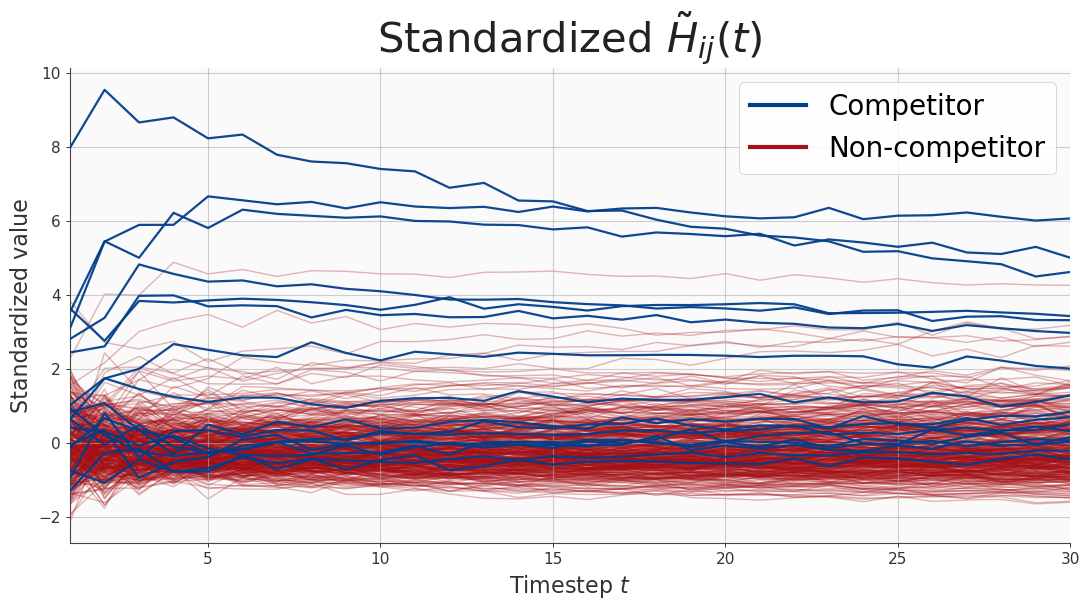

In [6]:
# ---- competitor pair mask ----
competitor_adj = np.asarray(rel_dict.get("competitor", np.zeros((n, n))))
is_comp_pair = np.array(
    [(competitor_adj[int(triu_i[k]), int(triu_j[k])] != 0
      or competitor_adj[int(triu_j[k]), int(triu_i[k])] != 0)
     for k in range(n_pairs)],
    dtype=bool,
)

BUCKETS = {
    "noncomp": {"color": "#a50f15", "lw": 1.0, "alpha": 0.30, "z": 0, "label": "Non-competitor"},
    "comp":    {"color": "#023e8a", "lw": 1.6, "alpha": 0.95, "z": 3, "label": "Competitor"},
}

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.set_facecolor("#fafafa")
for b in ["noncomp", "comp"]:   # back -> front
    spec = BUCKETS[b]
    idxs = np.where(is_comp_pair if b == "comp" else ~is_comp_pair)[0]
    for idx in idxs:
        ax.plot(t_array, Z[:, idx], color=spec["color"], linewidth=spec["lw"],
                alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=11)
ax.set_axisbelow(True)
ax.set_title(r"Standardized $\tilde H_{ij}(t)$", fontsize=30, pad=10, color="#222")
ax.set_xlabel(r"Timestep $t$", fontsize=16, color="#333")
ax.set_ylabel("Standardized value", fontsize=16, color="#333")

y_lo, y_hi = float(Z.min()), float(Z.max())
pad = 0.05 * (y_hi - y_lo)
ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlim(T_MIN_SHOW, T_MAX_SHOW)

legend_handles = [
    Line2D([0], [0], color=BUCKETS["comp"]["color"], lw=3, label=BUCKETS["comp"]["label"]),
    Line2D([0], [0], color=BUCKETS["noncomp"]["color"], lw=3, label=BUCKETS["noncomp"]["label"]),
]
leg = ax.legend(handles=legend_handles, loc="upper right", fontsize=20,
                frameon=True, framealpha=0.85, edgecolor="#cccccc")
leg.get_frame().set_linewidth(0.6)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

## 3. KMeans clustering -> estimated adjacency `adj_est`

Treat each pair's standardized Hessian time series as a feature vector and split them into two groups with KMeans (K=2). The cluster with the larger mean value is taken as the edge cluster, yielding `adj_est`.

In [7]:
FIX_K, N_INIT, BASE_SEED = 2, 10, 0

# transpose so each row is one pair's time series, then standardize again (feature axis = time)
X_pairs = Z.T.copy()
X_pairs = StandardScaler().fit_transform(X_pairs)

best_score, labels = -1.0, None
for r in range(N_INIT):
    km = KMeans(n_clusters=FIX_K, init="k-means++", n_init=1, random_state=BASE_SEED + r)
    lbl = km.fit_predict(X_pairs)
    sc = silhouette_score(X_pairs, lbl)
    if sc > best_score:
        best_score, labels = sc, lbl
best_K = FIX_K

# cluster with the largest mean value = edge cluster
cluster_means = np.array([X_pairs[labels == k].mean() for k in range(best_K)])
edge_cluster = int(np.argmax(cluster_means))

N = int(max(triu_i.max(), triu_j.max())) + 1
hess_companies = list(companies)[:N]
rel_dict_h = rel_dict

adj_est = np.zeros((N, N), dtype=np.int8)
for row, (i, j) in enumerate(zip(triu_i, triu_j)):
    if labels[row] == edge_cluster:
        adj_est[i, j] = 1
        adj_est[j, i] = 1

n_edges = int(np.triu(adj_est, k=1).sum())
density = 2.0 * n_edges / (N * (N - 1))
print(f"silhouette={best_score:.3f}, edge_cluster={edge_cluster}")
print(f"nodes={N}, estimated edges={n_edges}, density={density:.3f}")

silhouette=0.758, edge_cluster=1
nodes=28, estimated edges=15, density=0.040


In [8]:
# Estimated graph vs each ground-truth relationship, as fractions.
#   TPR = overlap / gt_edges                     (true positive rate / recall)
#   FDR = (predicted - overlap) / predicted      (false discovery rate)
#   JD  = (union - overlap) / union              (Jaccard distance = 1 - Jaccard)
# The table is produced for all nodes and again with Boeing removed.

def relationship_metric_table(keep_mask):
    """Compute TPR/FDR/JD (as fraction strings) over the nodes selected by keep_mask."""
    idx = np.where(keep_mask)[0]
    sub = np.ix_(idx, idx)
    ut = np.triu(np.ones((len(idx), len(idx)), dtype=bool), k=1)
    pred = adj_est.astype(bool)[sub] & ut
    n_pred = int(pred.sum())
    rows = []
    for r in REL_NAMES:
        if r not in rel_dict_h:
            continue
        A = np.asarray(rel_dict_h[r])[:N, :N] != 0
        A = (np.logical_or(A, A.T))[sub] & ut
        inter = int(np.logical_and(pred, A).sum())
        n_gt = int(A.sum())
        union = int(np.logical_or(pred, A).sum())
        rows.append({
            "relationship": r,
            "TPR": f"{inter}/{n_gt}",
            "FDR": f"{n_pred - inter}/{n_pred}",
            "JD":  f"{union - inter}/{union}",
        })
    return pd.DataFrame(rows), n_pred


keep_all = np.ones(N, dtype=bool)
keep_no_boeing = np.array([str(c).strip() != "Boeing" for c in companies[:N]], dtype=bool)

tbl_all, n_pred_all = relationship_metric_table(keep_all)
tbl_nb, n_pred_nb = relationship_metric_table(keep_no_boeing)

print(f"[All nodes]  N={N}, predicted edges={n_pred_all}")
print(tbl_all.to_string(index=False))

print(f"\n[Boeing excluded]  N={int(keep_no_boeing.sum())}, predicted edges={n_pred_nb}")
print(tbl_nb.to_string(index=False))

[All nodes]  N=28, predicted edges=15
relationship  TPR   FDR    JD
  competitor 7/17  8/15 18/25
    customer 4/25 11/15 32/36
  investment 1/12 14/15 25/26
 partnership 2/21 13/15 32/34
    supplier 4/25 11/15 32/36

[Boeing excluded]  N=27, predicted edges=15
relationship  TPR   FDR    JD
  competitor 7/12  8/15 13/20
    customer 4/18 11/15 25/29
  investment  1/8 14/15 21/22
 partnership 2/14 13/15 25/27
    supplier 4/18 11/15 25/29


## 4. Fix the node layout (`pos`)

Compute a spring layout from the union of the estimated graph and the five relationship graphs, then re-place each node on a ring according to its degree. A few companies are nudged manually to avoid label overlap.

In [9]:
union_adj = adj_est.astype(bool).copy()
for rname in REL_NAMES:
    if rname in rel_dict_h:
        A = np.asarray(rel_dict_h[rname])[:N, :N] != 0
        union_adj |= np.logical_or(A, A.T)
np.fill_diagonal(union_adj, False)

G_union = nx.Graph()
G_union.add_nodes_from(hess_companies)
for i in range(N):
    for j in range(i + 1, N):
        if union_adj[i, j]:
            G_union.add_edge(hess_companies[i], hess_companies[j])

degrees_u = dict(G_union.degree())
connected_u = [nn for nn, d in degrees_u.items() if d > 0]
isolated_u = [nn for nn, d in degrees_u.items() if d == 0]

pos = nx.spring_layout(G_union, seed=42, k=3.4 / np.sqrt(max(N, 1)), iterations=700)

# degree-based ring re-placement (higher degree -> more inward)
if connected_u:
    centroid = np.array([pos[nn] for nn in connected_u], dtype=float).mean(axis=0)
    rng = np.random.default_rng(42)
    angs = []
    for nn in connected_u:
        v = np.array(pos[nn], dtype=float) - centroid
        rr = float(np.linalg.norm(v))
        ang = float(np.arctan2(v[1], v[0])) if rr > 1e-9 else rng.uniform(0, 2 * np.pi)
        angs.append((nn, ang, degrees_u[nn]))
    angs.sort(key=lambda x: x[1])
    m = len(angs)
    deg_vals = np.array([a[2] for a in angs], dtype=float)
    dmin, dmax = deg_vals.min(), deg_vals.max()
    outer_r = 2.5
    for i, (nn, _, d) in enumerate(angs):
        theta = 2.0 * np.pi * i / max(m, 1)
        dn = (d - dmin) / (dmax - dmin) if dmax > dmin else 0.5
        r_new = outer_r - 0.7 * dn
        theta += rng.normal(0.0, 0.02)
        r_new += rng.normal(0.0, 0.03)
        pos[nn] = centroid + np.array([r_new * np.cos(theta), r_new * np.sin(theta)])

# manual position adjustments for a few nodes
for nm, shift in {
    "Boeing": (0.5, -0.5), "Johnson Controls": (0.0, 0.1),
    "Lockheed Martin": (0.4, 0.3), "Honeywell": (-0.1, 0.1), "Cummins": (-0.1, -0.1),
}.items():
    if nm in pos:
        pos[nm] = pos[nm] + np.array(shift)

# place isolated nodes on an outer ring
if isolated_u:
    center = (np.array([pos[nn] for nn in connected_u]).mean(axis=0)
              if connected_u else np.array([0.0, 0.0]))
    thetas = np.linspace(0, 2 * np.pi, num=len(isolated_u), endpoint=False)
    for k_, nn in enumerate(isolated_u):
        pos[nn] = center + 3.2 * np.array([np.cos(thetas[k_]), np.sin(thetas[k_])])

# common axis range
all_xy = np.array(list(pos.values()))
xmin, ymin = all_xy.min(axis=0) - 0.4
xmax, ymax = all_xy.max(axis=0) + 0.4
print(f"layout bbox: x[{xmin:.2f},{xmax:.2f}] y[{ymin:.2f},{ymax:.2f}]")

layout bbox: x[-2.74,2.86] y[-2.69,2.81]


In [10]:
# ---- label placement rules ----
center_xy = all_xy.mean(axis=0)

def angle_offset(name):
    """Push the label up/down/left/right based on the node angle relative to the centroid."""
    x, y = pos[name]
    deg_ = float(np.degrees(np.arctan2(y - center_xy[1], x - center_xy[0])))
    if -45 <= deg_ <= 45:        # right
        return (0.18, 0.0, "left", "center")
    elif 45 < deg_ <= 135:       # top
        return (0.0, 0.18, "center", "bottom")
    elif -135 <= deg_ < -45:     # bottom
        return (0.0, -0.22, "center", "top")
    else:                        # left
        return (-0.18, 0.0, "right", "center")

# manual overrides only for companies whose labels would overlap (dx, dy, ha, va)
manual_offsets = {
    "UPS":                           (0.00, 0.01, "left", "bottom"),
    "Huntington Ingalls Industries": (0.01, 0.01, "left", "bottom"),
    "Southwest Airlines":            (-0.01, -0.01, "right", "top"),
    "Delta Air Lines":               (0.00, 0.01, "center", "top"),
    "General Dynamics":              (0.01, 0.01, "left", "bottom"),
    "Paccar":                        (0.01, 0.00, "left", "bottom"),
    "Cummins":                       (0.01, 0.00, "left", "bottom"),
    "Waste Management":              (-0.01, -0.01, "right", "top"),
    "Republic Services":             (-0.01, -0.01, "right", "top"),
    "Boeing":                        (0.01, 0.01, "left", "center"),
    "Lockheed Martin":               (0.01, 0.01, "left", "bottom"),
    "Quanta Services":               (0.01, 0.01, "left", "bottom"),
    "Honeywell":                     (0.01, 0.01, "left", "bottom"),
    "TransDigm Group":               (0.01, 0.01, "left", "bottom"),
    "Equifax":                       (-0.01, -0.01, "right", "top"),
    "FedEx":                         (0.01, 0.01, "left", "bottom"),
    "Paychex":                       (-0.01, -0.01, "right", "top"),
    "ADP":                           (-0.01, -0.01, "right", "top"),
    "Wabtec":                        (-0.01, -0.01, "right", "top"),
    "United Rentals":                (0.01, 0.01, "left", "bottom"),
    "Ingersoll-Rand":                (-0.01, -0.01, "right", "top"),
    "Textron":                       (0.0, -0.01, "center", "top"),
    "Johnson Controls":              (-0.04, 0.03, "left", "bottom"),
    "Parker Hannifin":               (-0.02, -0.05, "left", "top"),
    "IDEX":                          (0.01, -0.02, "left", "top"),
    "Rockwell Automation":           (0.01, 0.01, "left", "bottom"),
    "Dover":                         (0.01, 0.01, "left", "bottom"),
    "Eaton":                         (0.01, 0.01, "left", "bottom"),
}

## 5. Estimated network graph

Draw the graph from the estimated `adj_est`. Edges are black, connected nodes red, isolated nodes gray. Labels are placed using the rules above (`manual_offsets` + `angle_offset`).

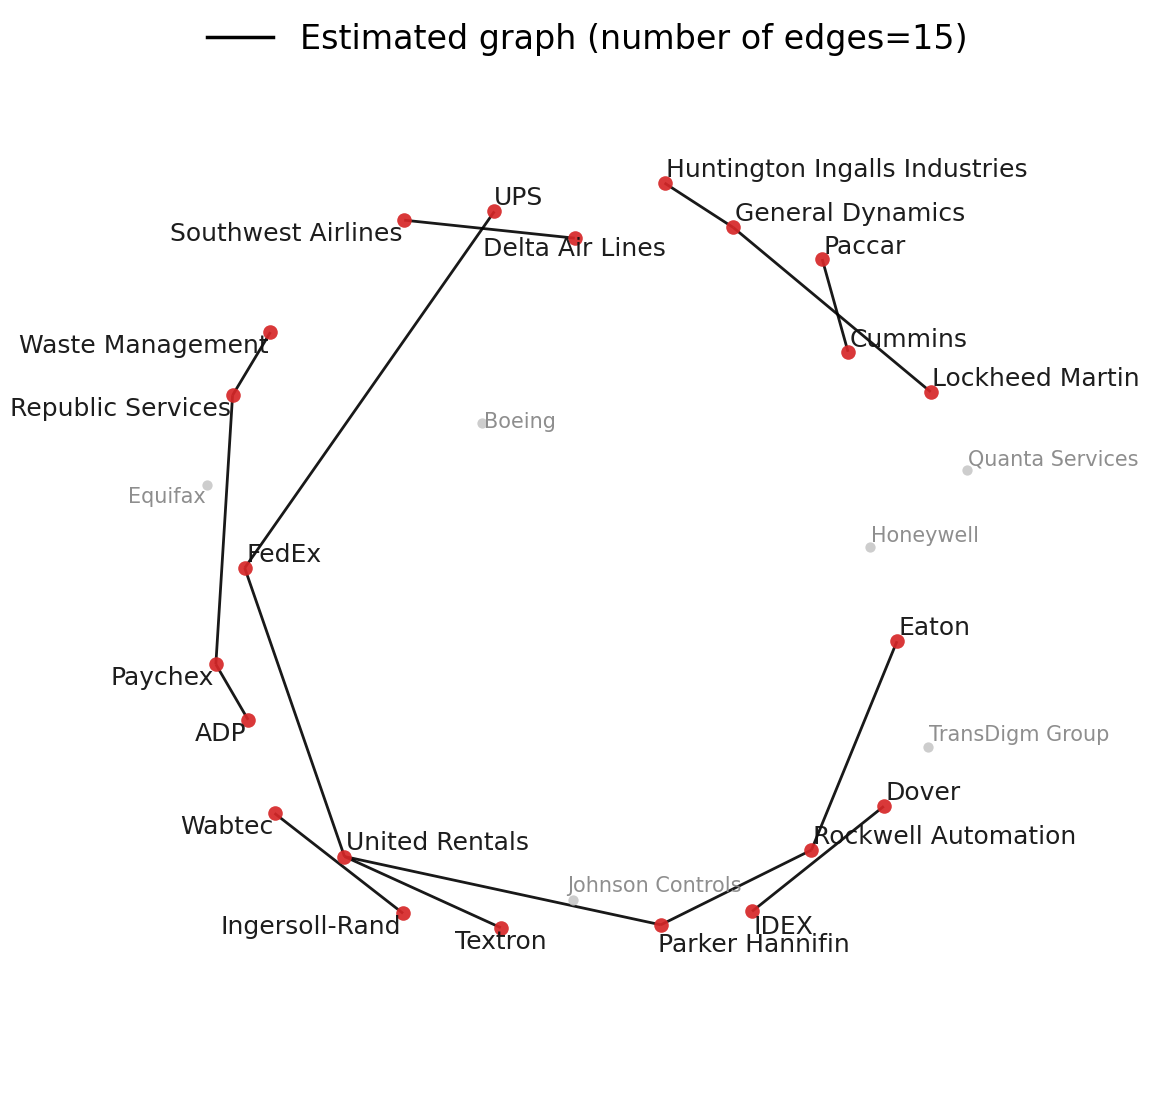

In [11]:
fig, ax = plt.subplots(figsize=(13, 11), facecolor="white")
ax.set_facecolor("#fbfbfb")

G_est = nx.Graph()
G_est.add_nodes_from(hess_companies)
edge_list = []
for i in range(N):
    for j in range(i + 1, N):
        if adj_est[i, j]:
            G_est.add_edge(hess_companies[i], hess_companies[j])
            edge_list.append((hess_companies[i], hess_companies[j]))

deg = dict(G_est.degree())
connected_nodes = [nn for nn, d in deg.items() if d > 0]
isolated_nodes = [nn for nn, d in deg.items() if d == 0]

nx.draw_networkx_edges(G_est, pos, ax=ax, edgelist=edge_list,
                       edge_color="black", width=2.0, alpha=0.9)
if connected_nodes:
    nx.draw_networkx_nodes(G_est, pos, ax=ax, nodelist=connected_nodes,
                           node_size=110, node_color="#d62728", alpha=0.92, linewidths=0)
if isolated_nodes:
    nx.draw_networkx_nodes(G_est, pos, ax=ax, nodelist=isolated_nodes,
                           node_size=55, node_color="#c5c5c5", alpha=0.85, linewidths=0)

for nn in hess_companies:
    color = "#111111" if deg[nn] > 0 else "#888888"
    fs = 18 if deg[nn] > 0 else 15
    dx, dy, ha, va = manual_offsets.get(nn, angle_offset(nn))
    ax.text(pos[nn][0] + dx, pos[nn][1] + dy, str(nn),
            fontsize=fs, color=color, alpha=0.95, ha=ha, va=va, zorder=10)

n_e = len(edge_list)
legend_handle = Line2D([0], [0], color="black", lw=2.5,
                       label=f"Estimated graph (number of edges={n_e})")
ax.legend(handles=[legend_handle], loc="upper center", bbox_to_anchor=(0.5, 1.03),
          frameon=False, fontsize=24)

pad = 0.6
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Ground-truth relationship graph (competitor)

Draw the ground-truth **competitor** relationship on the exact same node layout (`pos`) as the
estimated graph, so the two can be compared edge-by-edge. `draw_panel` is a reusable helper that
renders any binary adjacency matrix with the shared layout and label rules.

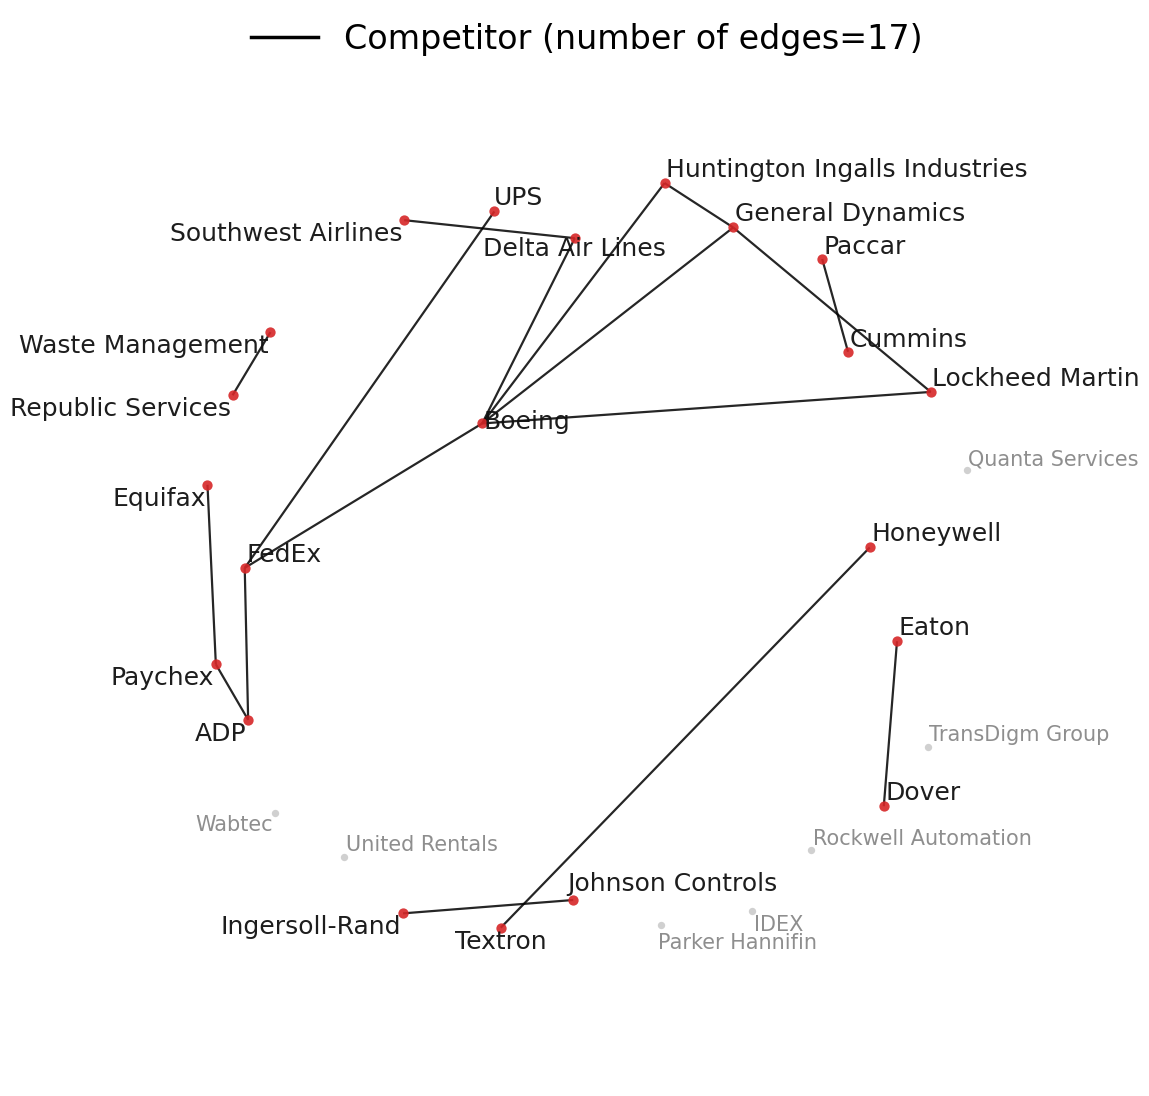

In [12]:
LABEL_PAD = 0.6
LABEL_FS_CONNECTED = 18
LABEL_FS_ISOLATED = 15


def draw_panel(ax, adj_mat, title, edge_color):
    """Draw a binary adjacency on the shared layout `pos` with the shared label rules."""
    ax.set_facecolor("#fbfbfb")
    G = nx.Graph()
    G.add_nodes_from(hess_companies)
    edge_list = []
    for i in range(N):
        for j in range(i + 1, N):
            if adj_mat[i, j]:
                G.add_edge(hess_companies[i], hess_companies[j])
                edge_list.append((hess_companies[i], hess_companies[j]))

    deg = dict(G.degree())
    connected_nodes = [nn for nn, d in deg.items() if d > 0]
    isolated_nodes = [nn for nn, d in deg.items() if d == 0]

    if edge_list:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge_list,
                               edge_color='black', width=1.6, alpha=0.85)
    if connected_nodes:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=connected_nodes,
                               node_size=55, node_color="#d62728", alpha=0.9, linewidths=0)
    if isolated_nodes:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=isolated_nodes,
                               node_size=28, node_color="#c5c5c5", alpha=0.8, linewidths=0)

    for nn in hess_companies:
        color = "#111111" if deg[nn] > 0 else "#888888"
        fs = LABEL_FS_CONNECTED if deg[nn] > 0 else LABEL_FS_ISOLATED
        dx, dy, ha, va = manual_offsets.get(nn, angle_offset(nn))
        ax.text(pos[nn][0] + dx, pos[nn][1] + dy, str(nn),
                fontsize=fs, color=color, alpha=0.95, ha=ha, va=va, zorder=10)

    n_e = len(edge_list)
    legend_handle = Line2D([0], [0], color=edge_color, lw=2.5,
                           label=f"{title} (number of edges={n_e})")
    ax.legend(handles=[legend_handle], loc="upper center", bbox_to_anchor=(0.5, 1.03),
              frameon=False, fontsize=24)
    ax.set_xlim(xmin - LABEL_PAD, xmax + LABEL_PAD)
    ax.set_ylim(ymin - LABEL_PAD, ymax + LABEL_PAD)
    ax.set_aspect("equal")
    ax.axis("off")
    return n_e


fig, ax = plt.subplots(1, 1, figsize=(13, 11), facecolor="white")

key = "competitor" #competitor or customer

if key == "competitor":
    title_name = 'Competitor'
elif key == "customer":
    title_name = 'Customer/Supplier'


A = np.asarray(rel_dict_h[key])[:N, :N] != 0
A = np.logical_or(A, A.T).astype(np.int8)
np.fill_diagonal(A, 0)
draw_panel(ax, A, title_name, 'black')

plt.tight_layout()
plt.show()

## 7. Standardized Hessian over t — clustering x competitor

Re-draw the standardized Hessian series, but split every pair into four buckets by crossing the
KMeans result (included vs excluded edge) with the competitor flag. Included pairs are drawn on
top in saturated colors; excluded non-competitor pairs fade into the background.

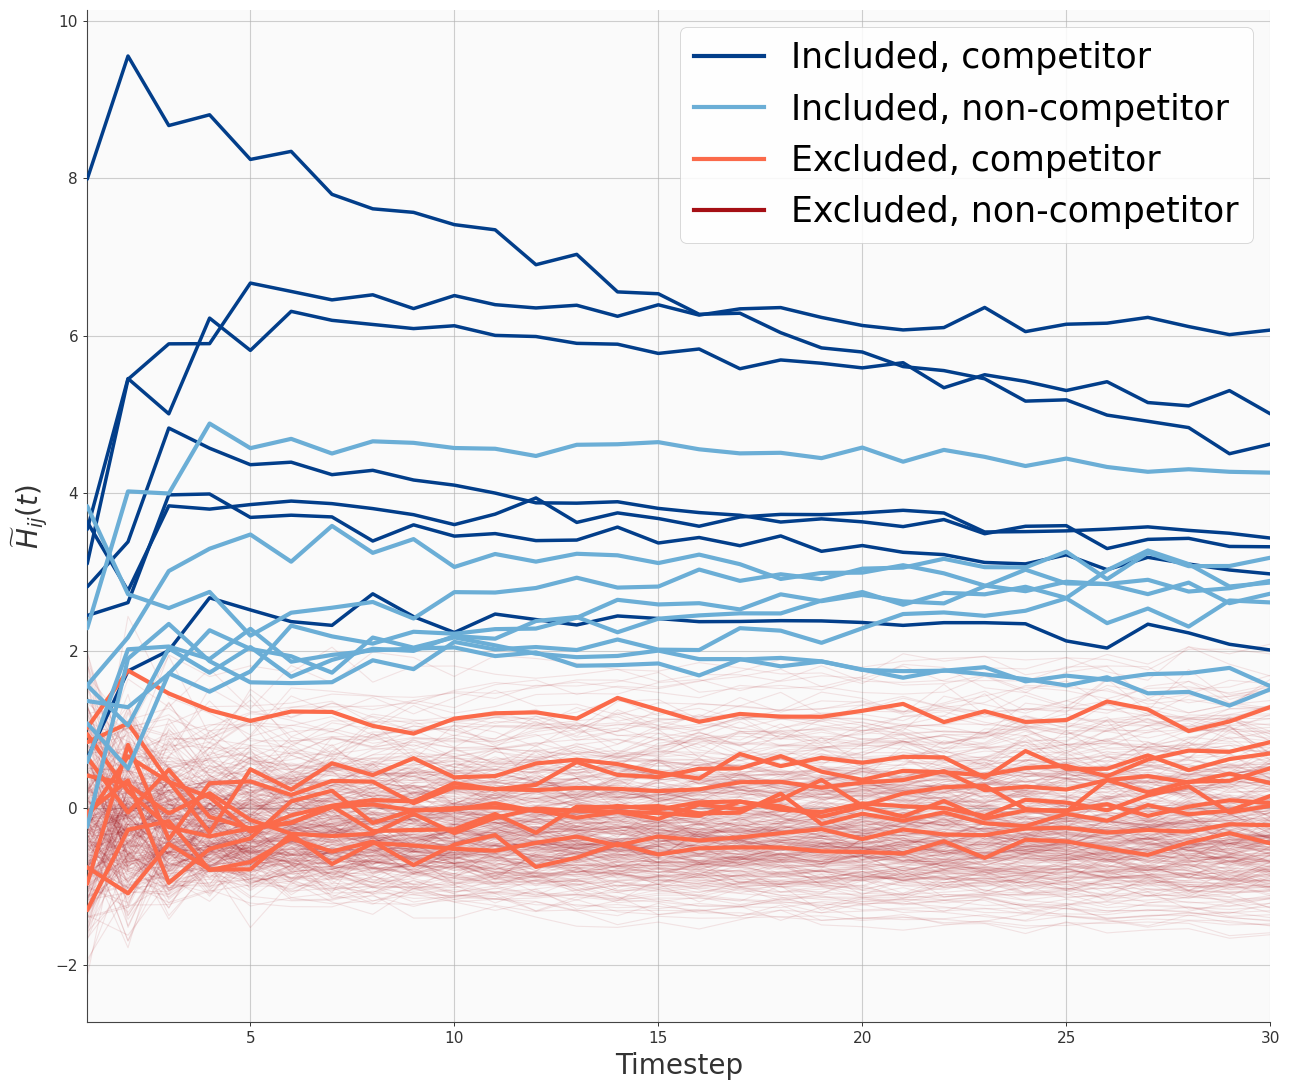

In [13]:
# included = pairs assigned to the edge cluster; excluded = the rest
is_included = (labels == edge_cluster)

BUCKETS = {
    "inc_comp":    {"color": "#023e8a", "lw": 2.5, "alpha": 1.0, "z": 4,  "label": "Included, competitor"},
    "inc_noncomp": {"color": "#6baed6", "lw": 3.0, "alpha": 1.0, "z": 10, "label": "Included, non-competitor"},
    "exc_comp":    {"color": "#fb6a4a", "lw": 3.0, "alpha": 1.0, "z": 10, "label": "Excluded, competitor"},
    "exc_noncomp": {"color": "#a50f15", "lw": 0.8, "alpha": 0.1, "z": 1,  "label": "Excluded, non-competitor"},
}

bucket_idx = {
    "exc_noncomp": np.where(~is_included & ~is_comp_pair)[0],
    "exc_comp":    np.where(~is_included &  is_comp_pair)[0],
    "inc_noncomp": np.where( is_included & ~is_comp_pair)[0],
    "inc_comp":    np.where( is_included &  is_comp_pair)[0],
}
# back -> front
draw_order = ["exc_noncomp", "exc_comp", "inc_noncomp", "inc_comp"]

fig, ax = plt.subplots(figsize=(13, 11))
ax.set_facecolor("#fafafa")
for b in draw_order:
    spec = BUCKETS[b]
    for idx in bucket_idx[b]:
        ax.plot(t_array, Z[:, idx], color=spec["color"], linewidth=spec["lw"],
                alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=11)
ax.set_axisbelow(True)
ax.set_xlabel("Timestep", fontsize=20, color="#333")
ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=20, color="#333")

y_lo, y_hi = float(Z.min()), float(Z.max())
pad = 0.05 * (y_hi - y_lo)
ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlim(T_MIN_SHOW, T_MAX_SHOW)

legend_order = ["inc_comp", "inc_noncomp", "exc_comp", "exc_noncomp"]
legend_handles = [Line2D([0], [0], color=BUCKETS[b]["color"], lw=3, label=BUCKETS[b]["label"])
                  for b in legend_order]
leg = ax.legend(handles=legend_handles, loc="upper right", fontsize=25,
                frameon=True, framealpha=0.85, edgecolor="#cccccc")
leg.get_frame().set_linewidth(0.6)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Pair ranking by mean standardized Hessian

Rank every company pair by its time-averaged standardized Hessian `mean_z` (descending). Larger
values are stronger edge candidates. The `competitor` column marks pairs that are competitors in
the ground truth.

In [14]:
import pandas as pd

order_z = np.argsort(-mean_z)   # descending

rows = []
for rk, k in enumerate(order_z, start=1):
    i, j = int(triu_i[k]), int(triu_j[k])
    rows.append({
        "rank": rk,
        "company1": companies[i],
        "company2": companies[j],
        "meanZ": mean_z[k],
        "competitor": "YES" if is_comp_pair[k] else "",
    })
ranking = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.width", 160)
fmt = {"meanZ": "{:7.3f}".format}

print(f"mean_z ranking (all {n_pairs} pairs, descending)")
print("=" * 70)
print(ranking.head(30).to_string(index=False, formatters=fmt))

mean_z ranking (all 378 pairs, descending)
 rank                      company1                      company2   meanZ competitor
    1             Republic Services              Waste Management   6.579        YES
    2                         FedEx                           UPS   6.125        YES
    3                       Cummins                        Paccar   5.599        YES
    4               Parker Hannifin           Rockwell Automation   4.398           
    5              General Dynamics               Lockheed Martin   3.787        YES
    6               Delta Air Lines            Southwest Airlines   3.653        YES
    7                           ADP                       Paychex   3.327        YES
    8                         Eaton           Rockwell Automation   2.976           
    9                         FedEx                United Rentals   2.892           
   10                Ingersoll-Rand                        Wabtec   2.369           
   11                 

## 9. Disagreement between estimate and competitor ground truth

Two groups where the KMeans estimate and the competitor ground truth disagree, each sorted by `meanZ` (descending):

- **Included but non-competitor** — pairs the estimate marks as edges that are *not* competitors in the ground truth (newly suggested relationships / false positives).
- **Competitor but excluded** — ground-truth competitor pairs the estimate *missed* (false negatives).

In [15]:
is_included = (labels == edge_cluster)


def disagreement_table(mask):
    """Build a meanZ-sorted table of pairs selected by `mask`."""
    rows = []
    for k in np.where(mask)[0]:
        i, j = int(triu_i[k]), int(triu_j[k])
        rows.append({
            "company1": companies[i],
            "company2": companies[j],
            "meanZ": mean_z[k],
        })
    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values("meanZ", ascending=False).reset_index(drop=True)
        df.insert(0, "rank", df.index + 1)
    return df


included_noncompetitor = disagreement_table(is_included & ~is_comp_pair)
competitor_excluded = disagreement_table(~is_included & is_comp_pair)

fmt = {"meanZ": "{:7.3f}".format}

print(f"Included but non-competitor  ({len(included_noncompetitor)} pairs)")
print("=" * 60)
print(included_noncompetitor.to_string(index=False, formatters=fmt))

print(f"\nCompetitor but excluded  ({len(competitor_excluded)} pairs)")
print("=" * 60)
print(competitor_excluded.to_string(index=False, formatters=fmt))

Included but non-competitor  (8 pairs)
 rank        company1            company2   meanZ
    1 Parker Hannifin Rockwell Automation   4.398
    2           Eaton Rockwell Automation   2.976
    3           FedEx      United Rentals   2.892
    4  Ingersoll-Rand              Wabtec   2.369
    5         Textron      United Rentals   2.366
    6 Parker Hannifin      United Rentals   2.084
    7           Dover                IDEX   1.821
    8         Paychex   Republic Services   1.761

Competitor but excluded  (10 pairs)
 rank       company1                      company2   meanZ
    1        Equifax                       Paychex   1.200
    2         Boeing              General Dynamics   0.531
    3         Boeing                         FedEx   0.374
    4         Boeing               Lockheed Martin   0.244
    5         Boeing               Delta Air Lines   0.091
    6            ADP                         FedEx  -0.029
    7         Boeing Huntington Ingalls Industries  -0.039
  